In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
)
from keras.regularizers import l2
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.utils import img_to_array, load_img


In [18]:
np.random.seed(42)
tf.random.set_seed(42)

In [19]:
# Load data set 

data_path = Path(r"/home/lenovo/Projects/Deep-Learning-Lab/data/FashionMNIST/raw")

train_images = np.fromfile(
    
    data_path / r"train-images-idx3-ubyte",
    dtype=np.uint8,
    offset = 16,
    
).reshape(-1, 28, 28)

train_labels= np.fromfile(
    data_path / r"train-labels-idx1-ubyte",
    dtype= np.uint8,
    offset= 8
)


test_images = np.fromfile(
    data_path / r"t10k-images-idx3-ubyte",
    dtype=np.uint8,
    offset = 16
    
).reshape(-1, 28, 28)

test_labels = np.fromfile(
    data_path / r"t10k-labels-idx1-ubyte",
    dtype= np.uint8,
    offset = 8
)

In [20]:
X_train, X_test = train_images, test_images
y_train, y_test = train_labels, test_labels

In [21]:
X_train = X_train.astype("float64") / 255.0
X_test = X_test.astype("float64") / 255.0

In [22]:
print(f"X_train shape{X_train.shape}")
print(f"X_test shape{X_test.shape}")
print(f"Y_train shape{y_train.shape}")
print(f"Y_test shape {y_test.shape}")

X_train shape(60000, 28, 28)
X_test shape(10000, 28, 28)
Y_train shape(60000,)
Y_test shape (10000,)


In [23]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

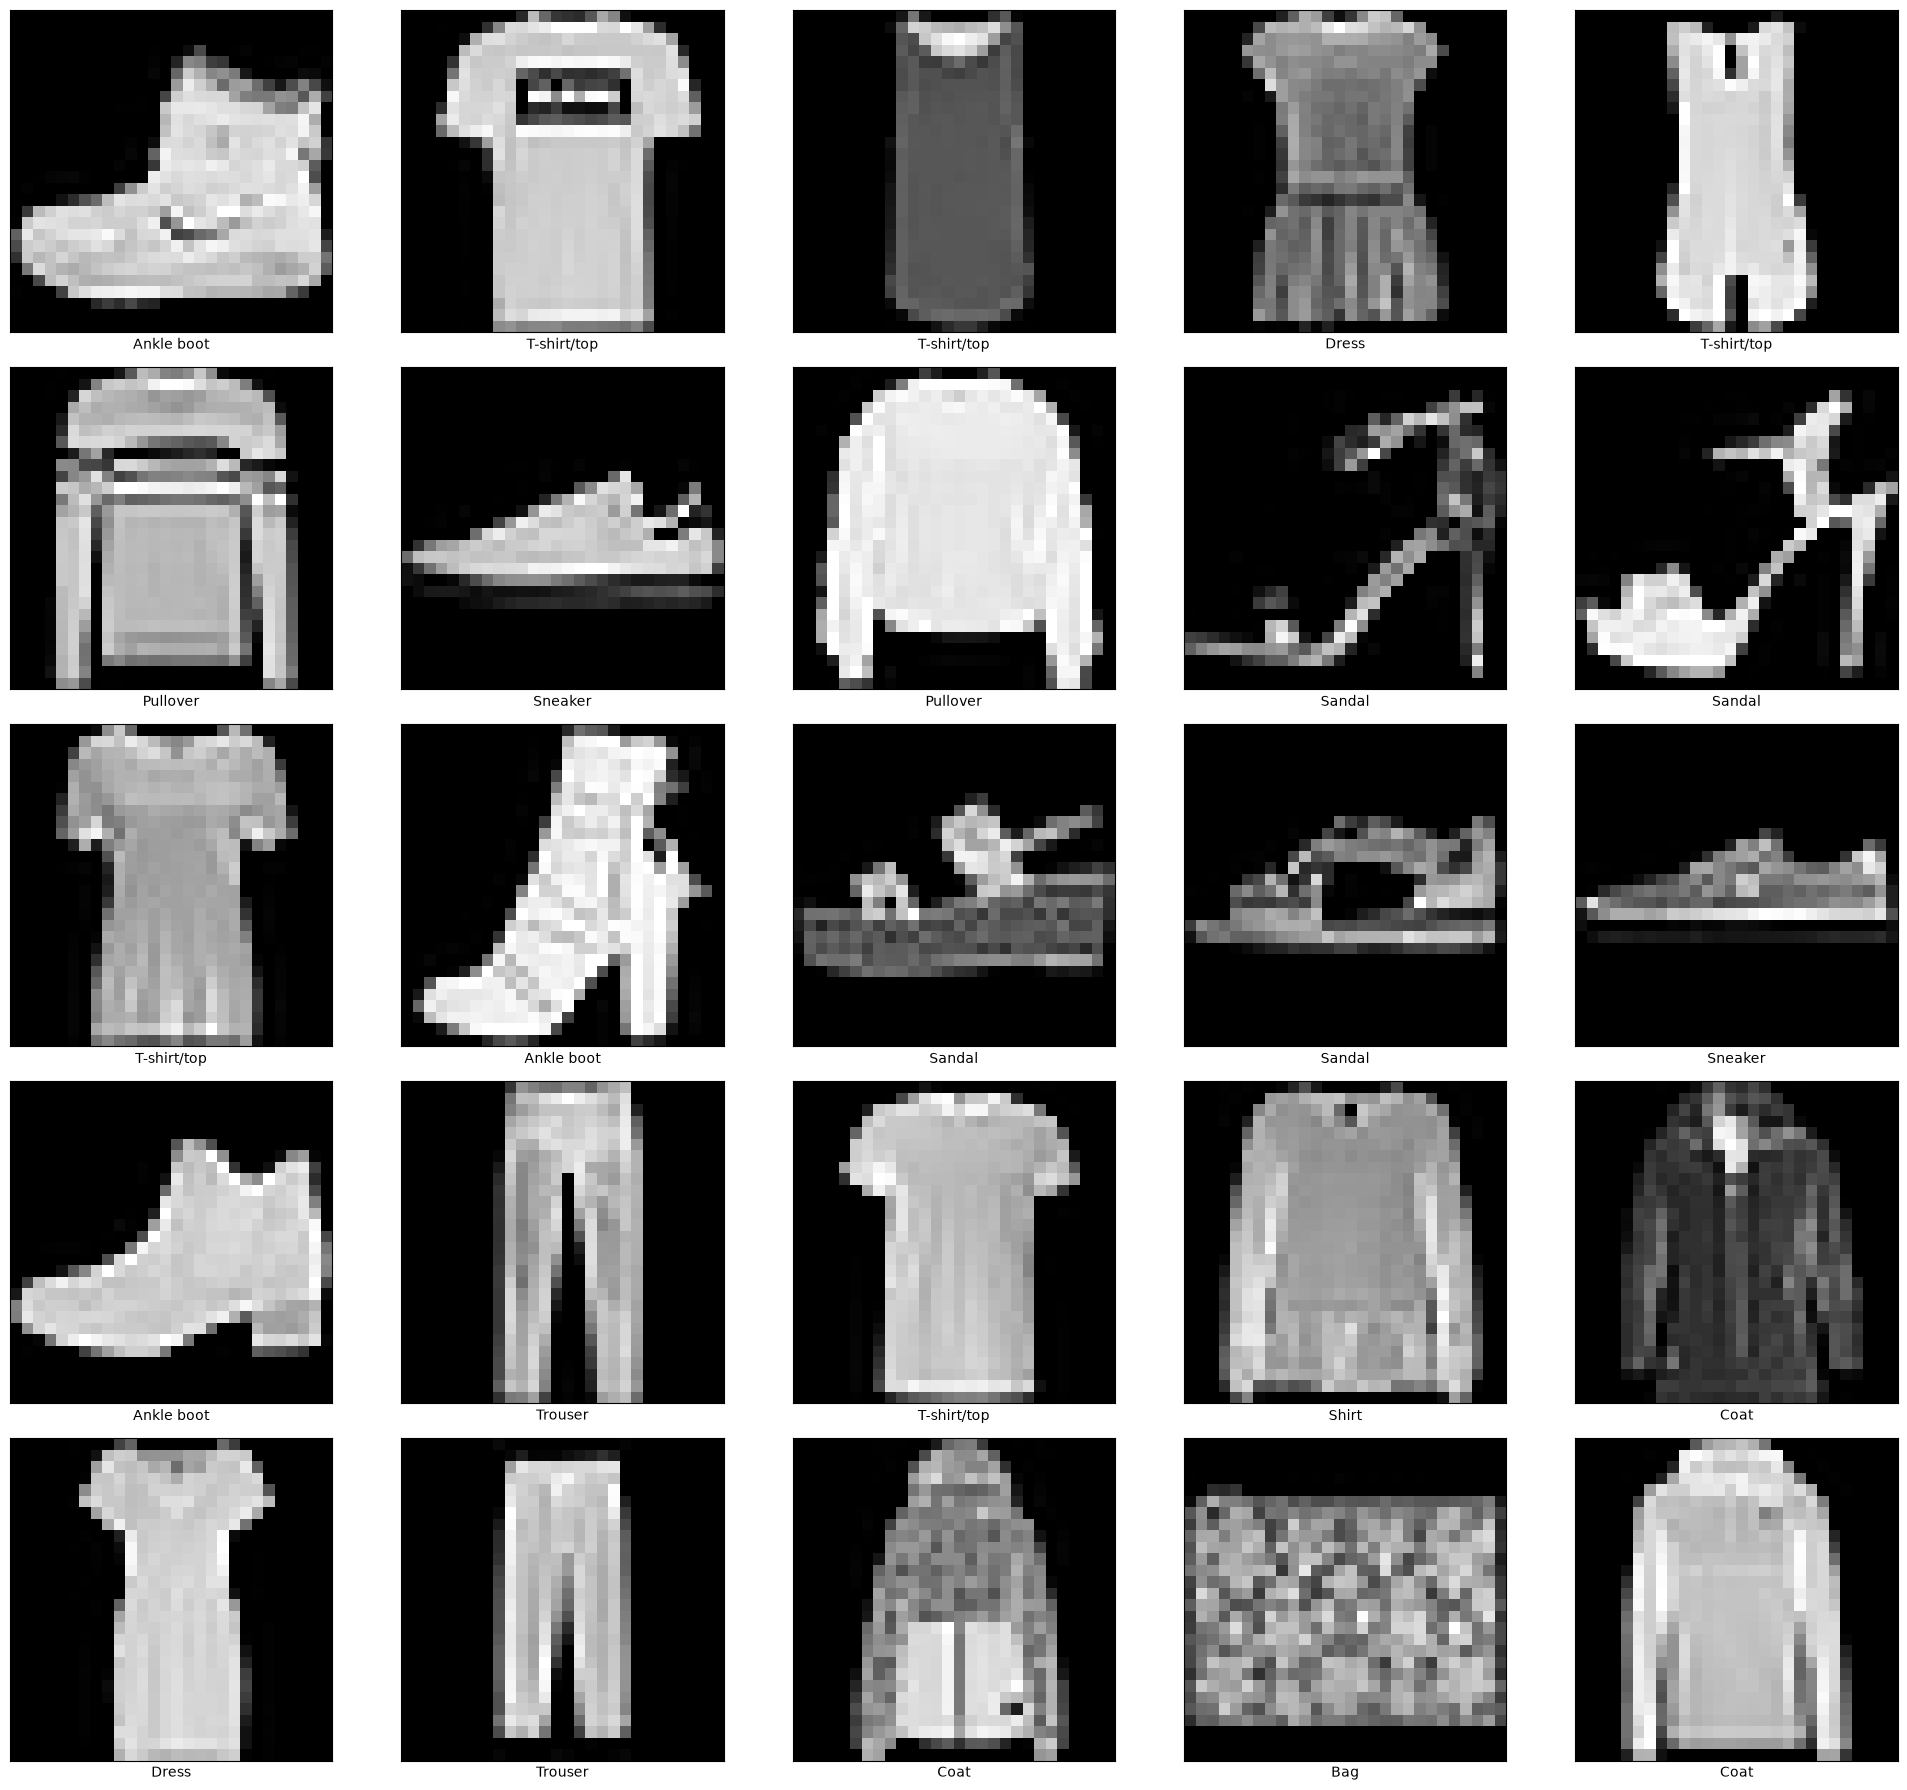

In [24]:
plt.figure(figsize = (20, 18))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    
    plt.imshow(X_train[i], cmap= "gray")
    plt.xlabel(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
    
    
plt.tight_layout()
plt.show()

In [56]:
model = Sequential([
    Input(shape=(28, 28, 1)),

    # Data Augmentation
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.05),

    # Block 1
    Conv2D(32, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    # Block 3
    Conv2D(128, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

In [57]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 313,642 (1.20 MB)

 Trainable params: 312,746 (1.19 MB)

 Non-trainable params: 896 (3.50 KB)

In [58]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


In [59]:
callbacks = [
    
    EarlyStopping(
        monitor= "val_loss",
        mode="min",
        min_delta= 1e-4,
        restore_best_weights = True,
        verbose=1,
        start_from_epoch =5,
        patience= 5,
    ),
    
    ReduceLROnPlateau(
        monitor="val_accuracy",
        mode = "max",
        patience= 3,
        verbose=1,
        factor=0.5,
        min_lr = 1e-6,
        min_delta=1e-4,
    )
]

In [60]:
X_train, X_val, y_train, y_val = train_test_split(X_train , y_train, test_size=0.2, random_state=42, stratify=y_train)

In [61]:
history = model.fit(
    X_train,
    y_train,
    validation_data = (X_val, y_val),
    verbose=1,
    epochs=200,
    batch_size=64,
    callbacks = callbacks
)

Epoch 1/200


E0000 00:00:1786802377.238071   22201 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_4_1/dropout_13_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


480/480 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6770 - loss: 0.9253 - val_accuracy: 0.6780 - val_loss: 0.9437 - learning_rate: 0.0010
Epoch 2/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8022 - loss: 0.6070 - val_accuracy: 0.8432 - val_loss: 0.5010 - learning_rate: 0.0010
Epoch 3/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8314 - loss: 0.5350 - val_accuracy: 0.8280 - val_loss: 0.5369 - learning_rate: 0.0010
Epoch 4/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8483 - loss: 0.4905 - val_accuracy: 0.8654 - val_loss: 0.4391 - learning_rate: 0.0010
Epoch 5/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8580 - loss: 0.4611 - val_accuracy: 0.8655 - val_loss: 0.4513 - learning_rate: 0.0010
Epoch 6/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8640 - loss: 0.4517 - val_accuracy: 0.8872 - val_loss: 0.3808 - learning_rate: 0.0010
Epoch 7/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8706 - loss: 

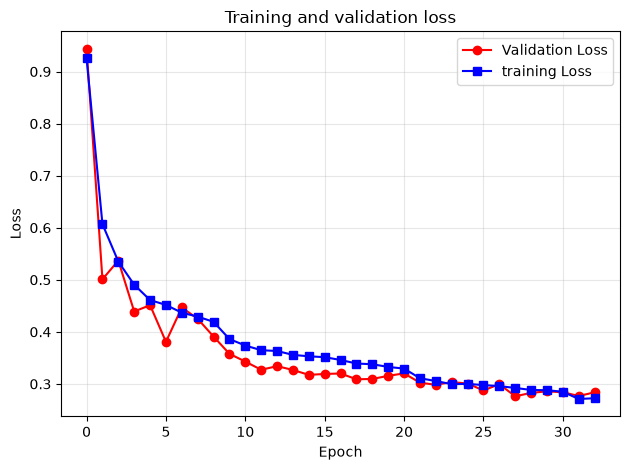

In [69]:
plt.figure()
plt.plot(history.history["val_loss"], marker="o", color="red", label="Validation Loss")
plt.plot(history.history["loss"], marker="s", color="blue", label="training Loss")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3),
plt.show()

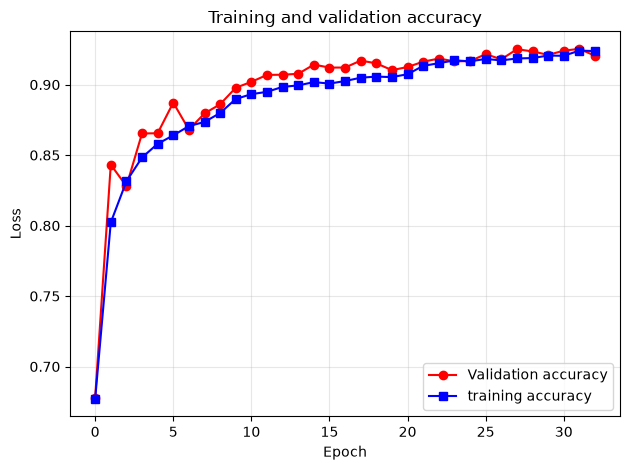

In [70]:
plt.figure()
plt.plot(history.history["val_accuracy"], marker="o", color="red", label="Validation accuracy")
plt.plot(history.history["accuracy"], marker="s", color="blue", label="training accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3),
plt.show()

In [71]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


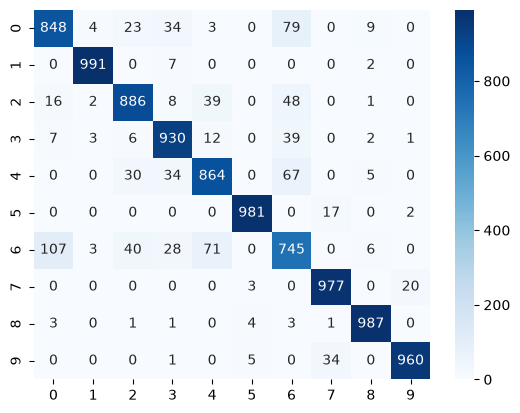

In [72]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot= True,
    fmt = "d",
    cbar= True,
    cmap="Blues",
)
plt.show()

In [73]:
report = classification_report(y_test, y_pred)

In [85]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred, average="weighted")}")
print(f"F1 score: {f1_score(y_test, y_pred,  average="weighted")}")
print(f"precision: {precision_score(y_test, y_pred,  average="weighted")}")

Accuracy: 0.9169
Recall: 0.9169
F1 score: 0.9166069030954394
precision: 0.9165017197779591


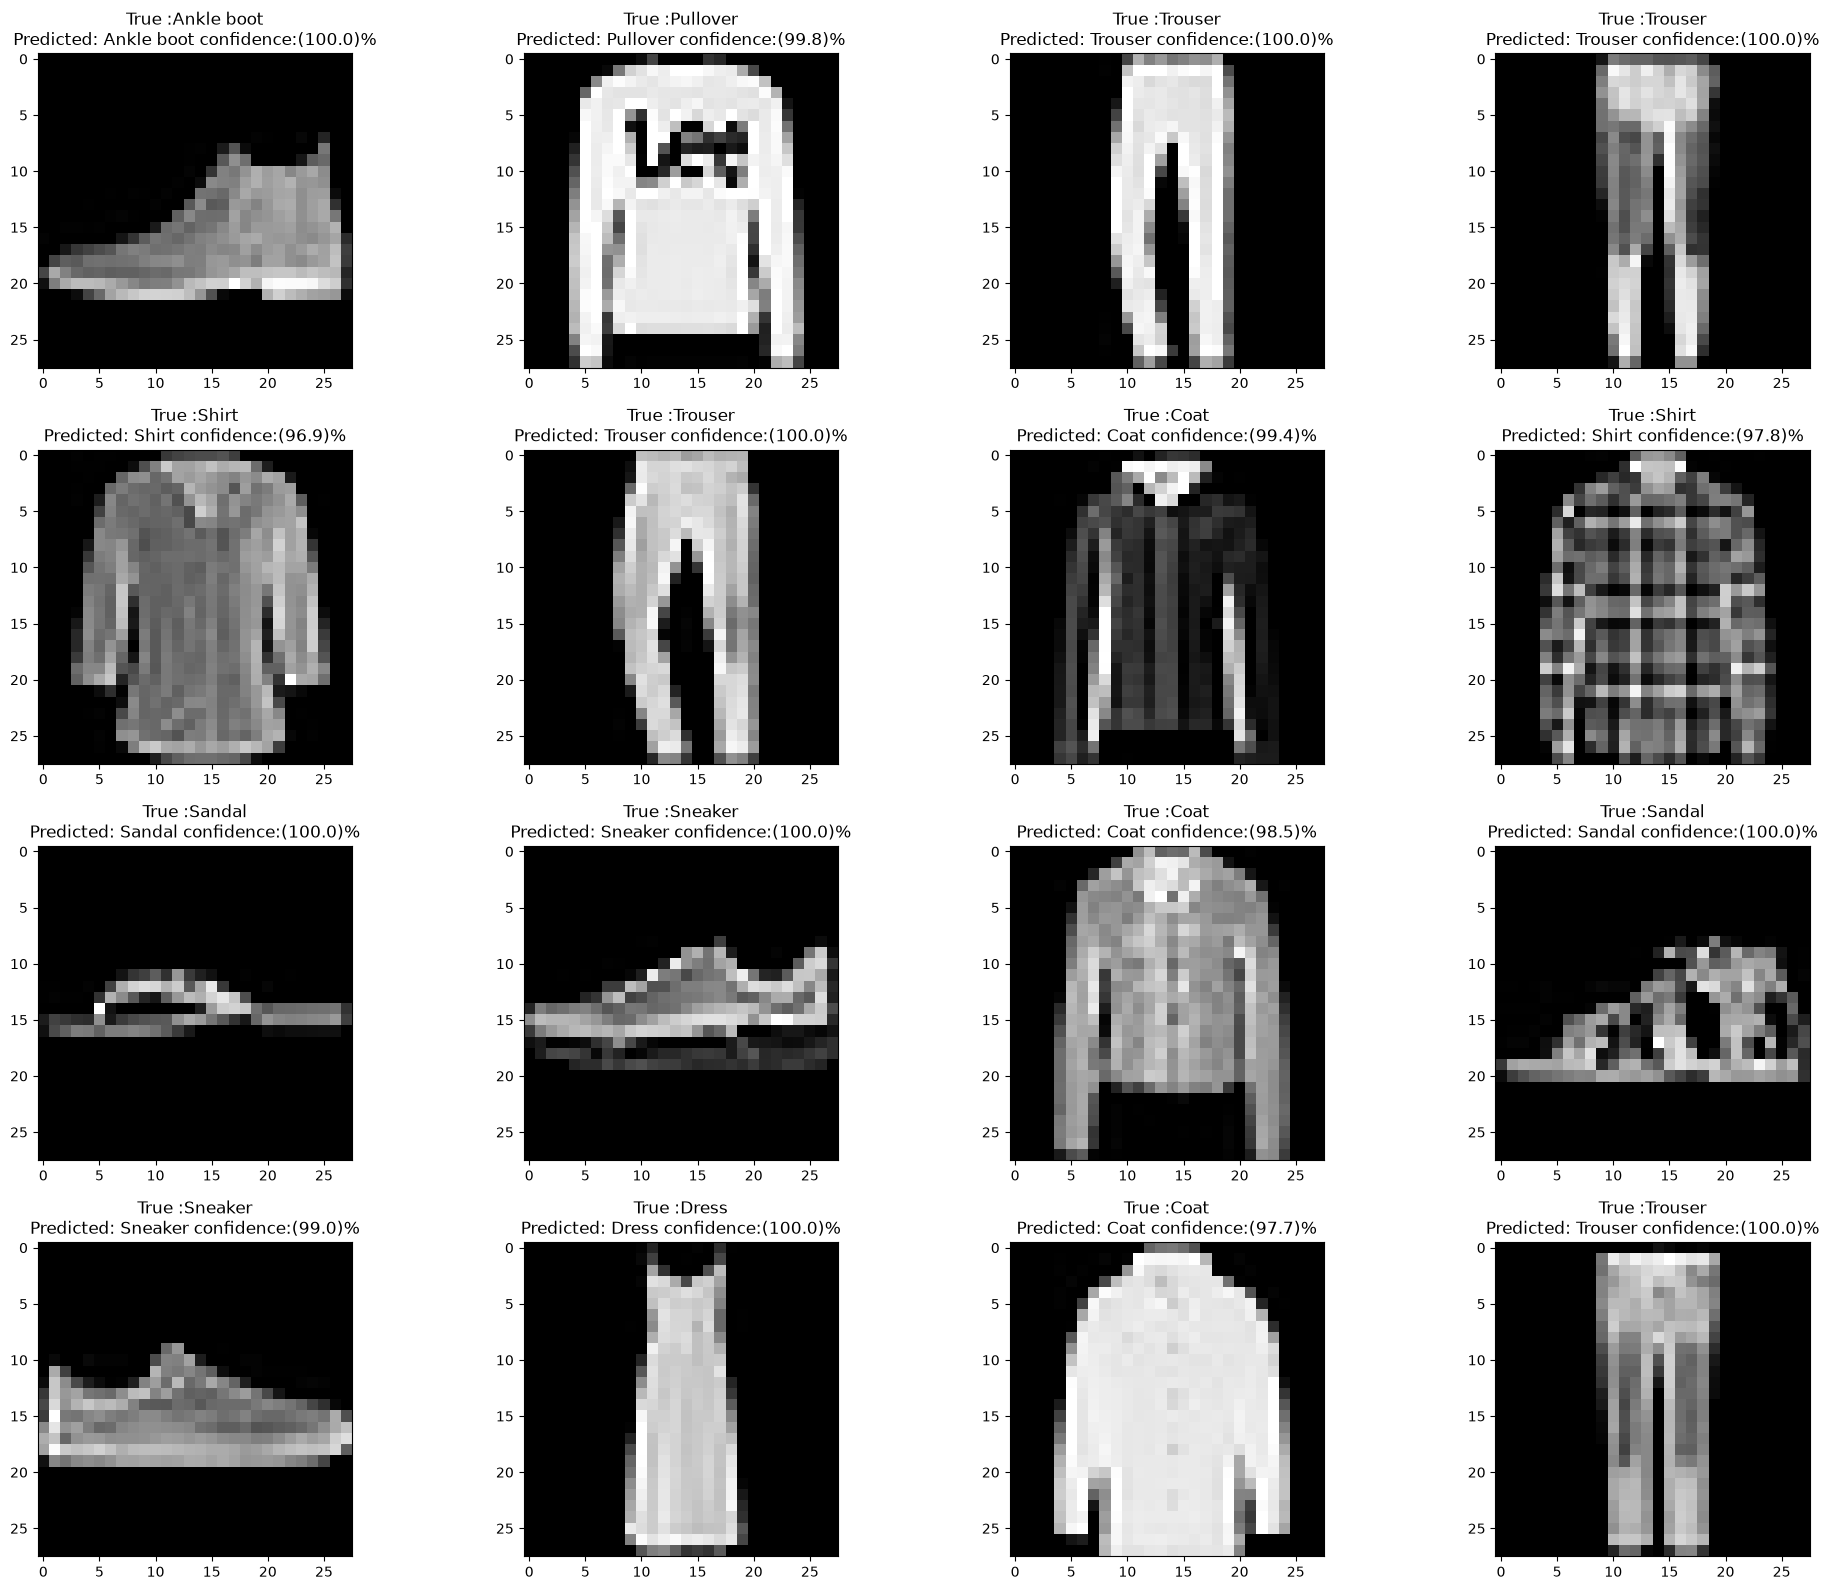

In [75]:
plt.figure(figsize=(20, 16))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    confidence = np.max(y_prob[i]) * 100
    plt.title(
        f"True :{class_names[y_test[i]]}\nPredicted: {class_names[y_pred[i]]} confidence:({confidence:0.1f})%"
    )
plt.tight_layout()
plt.show()

In [82]:
wrong_indices = np.where(y_test != y_pred)[0]
print(len(wrong_indices))

831


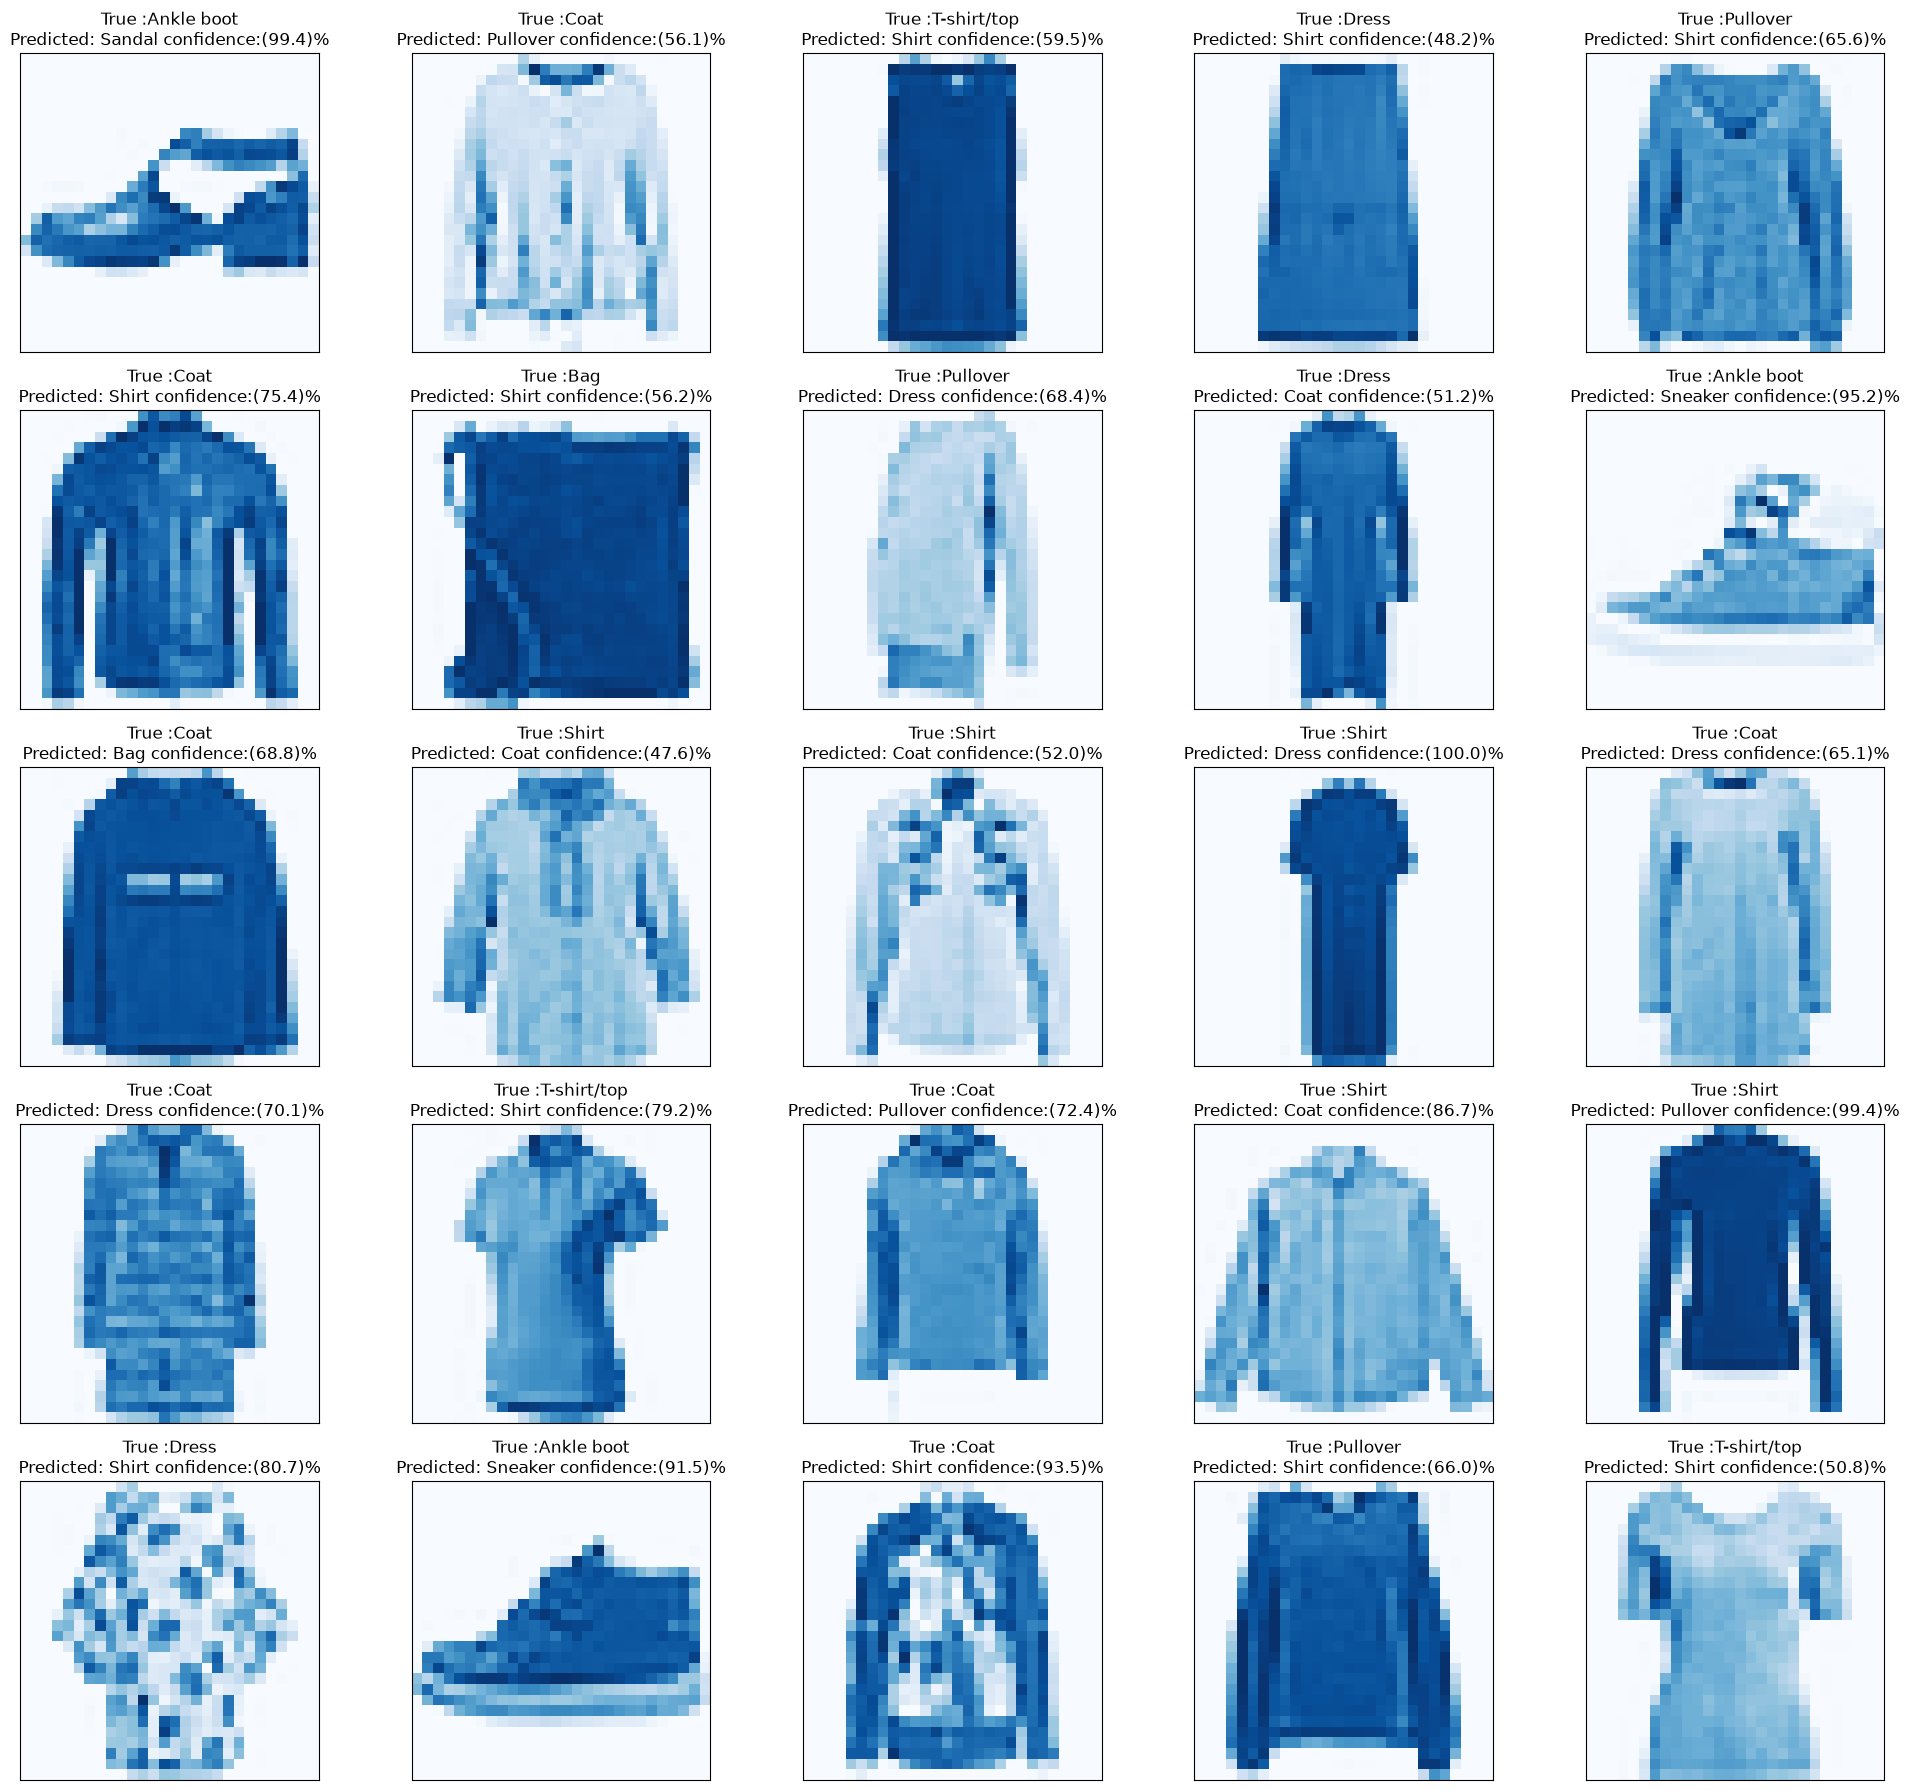

In [87]:
plt.figure(figsize=(20, 18))
for i, idx in enumerate(wrong_indices[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="Blues")
    confidence = np.max(y_prob[idx]) * 100
    plt.title(
          f"True :{class_names[y_test[idx]]}\nPredicted: {class_names[y_pred[idx]]} confidence:({confidence:0.1f})%"
    )
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()